In [2]:
import stim
from pyzx import *
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
steane = {
        "n": 7,
        "k": 1,
        "stabilizers": [
            "IIIXXXX",
            "IXXIIXX",
            "XIXIXIX",
            "IIIZZZZ",
            "IZZIIZZ",
            "ZIZIZIZ"
        ]
}
five_qubit = {
        "n" : 5,
        "k": 1,
        "stabilizers": [
            "XZZXI",
            "IXZZX",
            "XIXZZ",
            "ZXIXZ"
        ]
}


shor_code = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "ZZIIIIIII",
        "IZZIIIIII",
        "IIIZZIIII",
        "IIIIZZIII",
        "IIIIIIZZI",
        "IIIIIIIZZ",
        "XXXXXXIII",
        "IIIXXXXXX"
    ]
}
r3x3 = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "IZZIIIIII",
        "ZZIZZIIII",
        "IIIIIIZZI",
        "IIIIZZIZZ",
        "XIIXIIIII",
        "IXXIXXIII",
        "IIIXXIXXI",
        "IIIIIXIIX"
    ]
}
t2x2 = {
    "n": 8,
    "k": 2,
    "stabilizers": [
        "XXIXIIIX",
        "IIXIXXXI",
        "IIIXXXIX",
        "ZIZZZIII",
        "IZZZIZII",
        "ZIIIZIZZ"
    ]
}
t3x3 = {
    "n": 18,
    "k": 2,
    "stabilizers": [
        "XXIIXIIIIIIIIIIIXI",
        "IXXIIXIIIIIIIIIIIX",
        "IIIXIIXIXXIIIIIIII",
        "IIIIXIXXIIXIIIIIII",
        "IIIIIXIXXIIXIIIIII",
        "IIIIIIIIIXIIXIXXII",
        "IIIIIIIIIIXIXXIIXI",
        "IIIIIIIIIIIXIXXIIX",
        "IZIIZZIZIIIIIIIIII",
        "IIZZIZIIZIIIIIIIII",
        "IIIIIIZIIZZIZIIIII",
        "IIIIIIIZIIZZIZIIII",
        "IIIIIIIIZZIZIIZIII",
        "ZIIIIIIIIIIIZIIZZI",
        "IZIIIIIIIIIIIZIIZZ",
        "IIZIIIIIIIIIIIZZIZ"
    ]
}


In [1]:
def show_code(name, stabilizers):
    enc = stabilizers_to_ZX_graph(stabilizers)
    # g = GraphState(enc)
    # g.to_canonical_form()
    z = graph_to_ZXCF(enc)
    u = ZXCF_to_UGR(z)
    G = nx.Graph()

    adj_list = u.adj
    print(u.inputs)

    for x in range(len(adj_list)):
        if x in u.inputs:
            print(x)
            G.add_node(x, color="#4e598c")
        else:
            G.add_node(x, color="#ff8c42")

    for u, neighbors in enumerate(adj_list):
        for v in neighbors:
            G.add_edge(u, v)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=30)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]


    nx.draw(G, pos, 
            node_color=node_colors, 
            node_size=600, 
            font_weight='bold')

    # plt.title("Graph from Index-Based Adjacency List")
    plt.savefig(f"plots/{name}")
    plt.show()

show_code("steane",steane["stabilizers"])
show_code("shor",shor_code["stabilizers"])
show_code("five_qubit",five_qubit["stabilizers"])
show_code("rotated",r3x3["stabilizers"])
show_code("toric2x2", t2x2["stabilizers"])
show_code("toric3x3",t3x3["stabilizers"])



NameError: name 'steane' is not defined

In [ ]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=30)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("7 qubit code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)
net.toggle_physics(True)

[stim.PauliString("+XX_X___X"), stim.PauliString("+__X_XXX_"), stim.PauliString("+___XXX_X"), stim.PauliString("+Z_ZZZ___"), stim.PauliString("+_ZZZ_Z__"), stim.PauliString("+Z___Z_ZZ")]
8 2
spider_simp: 15. 10. 5. 3. 3. 3. 2. 2. 1. 1.  10 iterations
id_simp: 4.  1 iterations
spider_simp: 3. 3. 2. 1. 1.  5 iterations
pivot_simp: 1.  1 iterations
pivot_boundary_simp: 1.  1 iterations
lcomp_simp: 1. 1.  2 iterations
[]


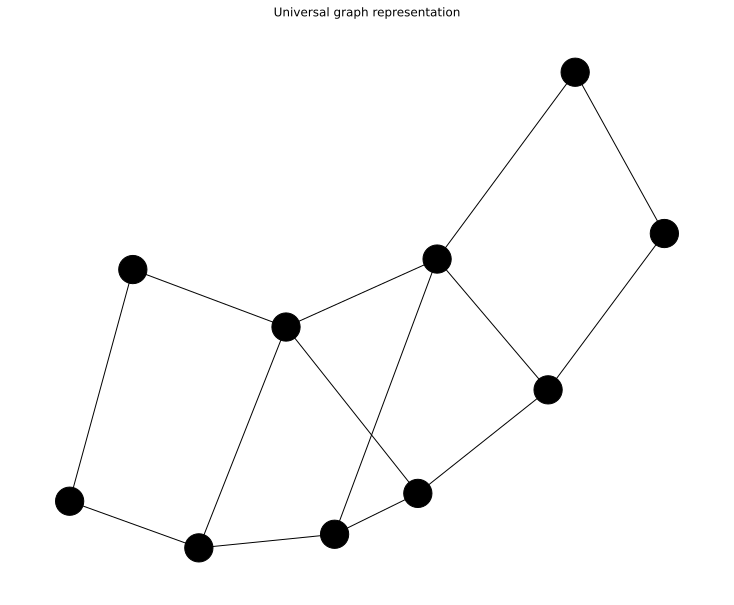

In [51]:
enc = tableau_to_graph_encoder(toric_code_2)
g = GraphState(enc)
g.to_canonical_form()
z = graph_to_universal_representation(enc)
u = to_universal_graph_representation(z)
G = nx.Graph()

adj_list = u.adj
print(u.inputs)

for x in range(len(adj_list)):
    if x in u.inputs:
        print(x)
        G.add_node(x, color="red")
    else:
        G.add_node(x, color="black")

for u, neighbors in enumerate(adj_list):
    for v in neighbors:
        G.add_edge(u, v)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)

node_colors = [G.nodes[n]['color'] for n in G.nodes()]


nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=800, 
        font_weight='bold')

plt.title("Universal graph representation")
plt.show()
